# 05. Lựa chọn feature và tối ưu hóa nhẹ

Notebook này tương ứng **Bước 5: Lựa chọn feature, tối ưu hóa mô hình**.

Mục tiêu:
- Xếp hạng feature bằng Random Forest importance.
- Xếp hạng feature bằng Mutual Information.
- Chọn top feature bằng SelectKBest.
- So sánh full features và selected features.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

DEFAULT_ROOT = Path(r"C:\vscode\hoctap\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents, DEFAULT_ROOT]:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Khong tim thay project root.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import preprocess_pipeline
from src.utils.config import load_project_config

sns.set_theme(style='whitegrid')
config = load_project_config(PROJECT_ROOT / 'configs' / 'config.yaml')
random_state = config['project']['random_state']
df = load_dataset(PROJECT_ROOT / config['paths']['raw_data'])
bundle = preprocess_pipeline(df, config)
X_train, X_test = bundle.X_train, bundle.X_test
y_train, y_test = bundle.y_train, bundle.y_test
feature_names = bundle.feature_names
print(X_train.shape, X_test.shape)

(8278, 19) (1409, 19)


## 1. Random Forest Feature Importance

Dang xep hang feature bang Random Forest...
Hoan thanh Random Forest feature importance.


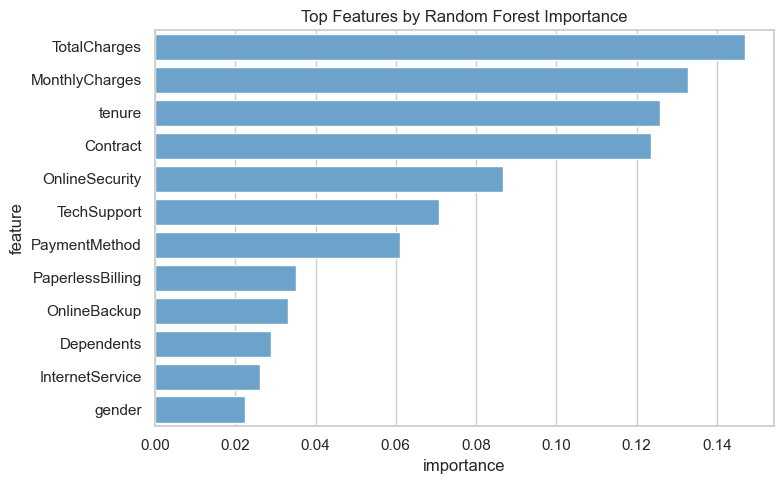

,feature,importance
18,TotalCharges,0.146900
17,MonthlyCharges,0.132864
4,tenure,0.125880
14,Contract,0.123472
8,OnlineSecurity,0.086635
11,TechSupport,0.070759
16,PaymentMethod,0.061122
15,PaperlessBilling,0.035256
9,OnlineBackup,0.033133
3,Dependents,0.028817


In [2]:
print('Dang xep hang feature bang Random Forest...')
rf_selector = RandomForestClassifier(n_estimators=120, random_state=random_state, n_jobs=-1)
rf_selector.fit(X_train, y_train)
print('Hoan thanh Random Forest feature importance.')

rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance.head(12), x='importance', y='feature', color='#5DA5DA')
plt.title('Top Features by Random Forest Importance')
plt.tight_layout()
plt.show()

rf_importance.head(12)

## 2. Mutual Information

Dang tinh Mutual Information...
Hoan thanh Mutual Information.


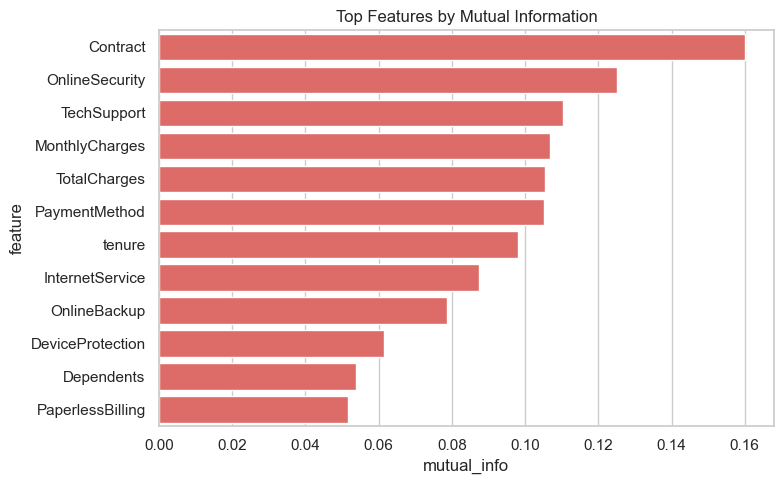

,feature,mutual_info
14,Contract,0.159973
8,OnlineSecurity,0.125048
11,TechSupport,0.110382
17,MonthlyCharges,0.106668
18,TotalCharges,0.105317
16,PaymentMethod,0.105080
4,tenure,0.098036
7,InternetService,0.087410
9,OnlineBackup,0.078692
10,DeviceProtection,0.061600


In [3]:
print('Dang tinh Mutual Information...')
mi_scores = mutual_info_classif(X_train, y_train, random_state=random_state)
print('Hoan thanh Mutual Information.')
mi_importance = pd.DataFrame({
    'feature': feature_names,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=mi_importance.head(12), x='mutual_info', y='feature', color='#F15854')
plt.title('Top Features by Mutual Information')
plt.tight_layout()
plt.show()

mi_importance.head(12)

## 3. SelectKBest chọn top 12 feature

In [4]:
k = min(12, X_train.shape[1])
print(f'Dang chon top {k} feature bang SelectKBest...')
selector = SelectKBest(score_func=mutual_info_classif, k=k)
selector.fit(X_train, y_train)
print('Hoan thanh SelectKBest.')
selected_features = X_train.columns[selector.get_support()].tolist()
selected_scores = pd.DataFrame({
    'feature': X_train.columns,
    'selectkbest_score': selector.scores_,
    'selected': selector.get_support()
}).sort_values('selectkbest_score', ascending=False)

print('Selected features:', selected_features)
selected_scores.head(15)

Dang chon top 12 feature bang SelectKBest...
Hoan thanh SelectKBest.
Selected features: ['tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


,feature,selectkbest_score,selected
14,Contract,0.146541,True
8,OnlineSecurity,0.117908,True
11,TechSupport,0.113998,True
16,PaymentMethod,0.109600,True
17,MonthlyCharges,0.109435,True
18,TotalCharges,0.104235,True
4,tenure,0.099379,True
7,InternetService,0.089579,True
9,OnlineBackup,0.075491,True
10,DeviceProtection,0.067562,True


## 4. So sánh full features và selected features

In [5]:
models = {
    'logistic_regression': LogisticRegression(max_iter=2000, random_state=random_state),
    'random_forest': RandomForestClassifier(n_estimators=120, max_depth=10, random_state=random_state, n_jobs=-1),
    'gradient_boosting': GradientBoostingClassifier(random_state=random_state),
}

def evaluate_feature_set(model_name, model, feature_set_name, train_X, test_X):
    model.fit(train_X, y_train)
    pred = model.predict(test_X)
    if hasattr(model, 'predict_proba'):
        roc_auc = roc_auc_score(y_test, model.predict_proba(test_X)[:, 1])
    else:
        roc_auc = np.nan
    return {
        'model': model_name,
        'feature_set': feature_set_name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc,
    }

rows = []
for model_name, model in models.items():
    print(f'Dang train {model_name} voi full features...')
    rows.append(evaluate_feature_set(model_name, model, 'full_features', X_train, X_test))
    print(f'Dang train {model_name} voi selected features...')
    rows.append(evaluate_feature_set(model_name, model.__class__(**model.get_params()), 'selected_features', X_train[selected_features], X_test[selected_features]))

print('Hoan thanh so sanh full features va selected features.')

feature_comparison_df = pd.DataFrame(rows).sort_values(['model', 'feature_set'])

metrics_dir = PROJECT_ROOT / 'models' / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)
feature_comparison_path = metrics_dir / 'feature_selection_comparison.csv'
selected_features_path = metrics_dir / 'selected_features.csv'

feature_comparison_df.to_csv(feature_comparison_path, index=False)
pd.DataFrame({'feature': selected_features}).to_csv(selected_features_path, index=False)

print('Da luu bang so sanh feature tai:', feature_comparison_path)
print('Da luu danh sach selected features tai:', selected_features_path)
feature_comparison_df

Dang train logistic_regression voi full features...
Dang train logistic_regression voi selected features...
Dang train random_forest voi full features...
Dang train random_forest voi selected features...
Dang train gradient_boosting voi full features...
Dang train gradient_boosting voi selected features...
Hoan thanh so sanh full features va selected features.
Da luu bang so sanh feature tai: C:\vscode\hoctap\Customer-Churn-Analysis\models\metrics\feature_selection_comparison.csv
Da luu danh sach selected features tai: C:\vscode\hoctap\Customer-Churn-Analysis\models\metrics\selected_features.csv


,model,feature_set,accuracy,precision,recall,f1,roc_auc
4,gradient_boosting,full_features,0.757275,0.533333,0.684492,0.599532,0.828262
5,gradient_boosting,selected_features,0.765082,0.543967,0.711230,0.616454,0.833898
0,logistic_regression,full_features,0.736693,0.502814,0.716578,0.590959,0.815531
1,logistic_regression,selected_features,0.740241,0.507246,0.748663,0.604752,0.822974
2,random_forest,full_features,0.765791,0.548035,0.671123,0.603365,0.828015
3,random_forest,selected_features,0.766501,0.549020,0.673797,0.605042,0.830005


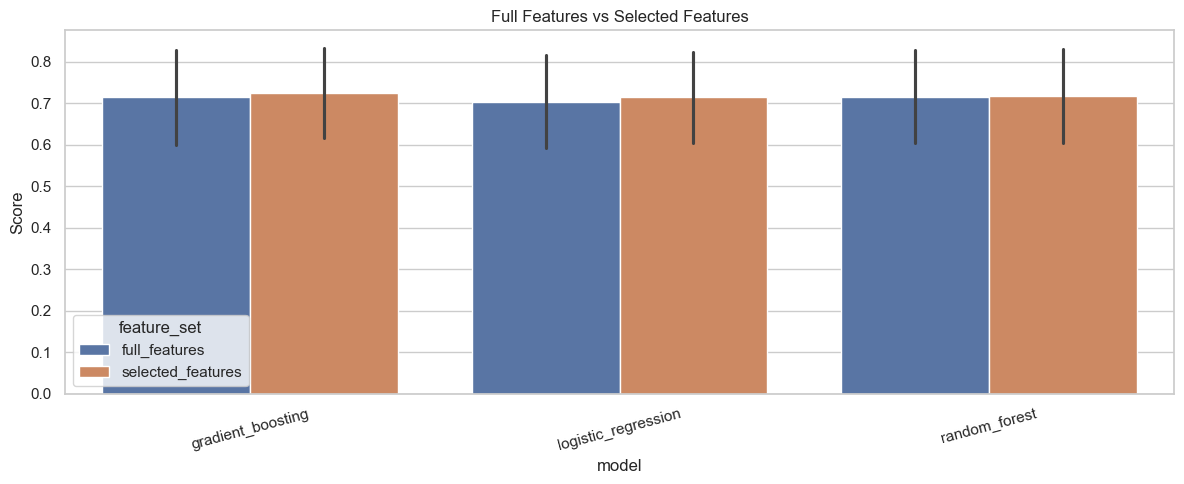

,model,feature_set,accuracy,precision,recall,f1,roc_auc
5,gradient_boosting,selected_features,0.765082,0.543967,0.711230,0.616454,0.833898
3,random_forest,selected_features,0.766501,0.549020,0.673797,0.605042,0.830005
1,logistic_regression,selected_features,0.740241,0.507246,0.748663,0.604752,0.822974
2,random_forest,full_features,0.765791,0.548035,0.671123,0.603365,0.828015
4,gradient_boosting,full_features,0.757275,0.533333,0.684492,0.599532,0.828262
0,logistic_regression,full_features,0.736693,0.502814,0.716578,0.590959,0.815531


In [6]:
plot_df = feature_comparison_df.melt(
    id_vars=['model', 'feature_set'],
    value_vars=['f1', 'roc_auc'],
    var_name='metric',
    value_name='score'
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x='model', y='score', hue='feature_set')
plt.title('Full Features vs Selected Features')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

feature_comparison_df.sort_values('f1', ascending=False)

## Kết luận bước 5

- Nếu selected features có điểm tốt hơn, có thể nói feature selection giúp giảm nhiễu.
- Nếu full features tốt hơn, vẫn kết luận trung thực rằng full features phù hợp hơn cho mô hình cuối.
- Dù kết quả thế nào, feature selection vẫn giúp xác định biến quan trọng để giải thích churn.